In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
from astropy.table import Table
from astropy.io import fits
import seaborn as sns
from matplotlib.animation import PillowWriter
import matplotlib as mpl
from matplotlib.ticker import FormatStrFormatter
from matplotlib.colors import TwoSlopeNorm
import matplotlib.colors as mcolors
import random

params = {
   'axes.labelsize': 15,
   'font.size': 15,
   'legend.fontsize': 14,
   'xtick.minor.visible': True,
   'ytick.minor.visible': True,
   'xtick.labelsize': 15,
   'ytick.labelsize': 15,
   'text.usetex': True, #to use TeX in your labels
   'font.family':'serif',
   'axes.titlesize': 15,
   'xtick.direction': 'in',
   'ytick.direction': 'in',
   'xtick.top': True,
   'ytick.right': True,
   'xtick.major.size': 6,
   'xtick.minor.size': 3,
   'ytick.major.size': 6,
   'ytick.minor.size': 3
   }
rcParams.update(params)

import pandas as pd
from astropy.io import fits
from astropy.table import Table

def decode(df):
    """
    Decode DataFrame with byte strings into ordinary strings.
    """
    str_df = df.select_dtypes([object])
    str_df = str_df.stack().str.decode('utf-8').unstack()
    for col in str_df:
        df[col] = str_df[col]
    return df

def fitsrec_to_pandas(fits_rec):
    """
    Convert a FITS_rec object (from astropy.io.fits) to a pandas DataFrame.
    """
    # Convert FITS_rec to astropy Table first
    table = Table(fits_rec)
    
    # Filter out multidimensional columns
    cols = [name for name in table.colnames if len(table[name].shape) <= 1]
    
    # Convert to pandas DataFrame
    df = table[cols].to_pandas()
    
    # Decode byte strings
    df = decode(df)
    
    return df

def compute_binned_median(df, x_col, y_col, n_bins=12):
    """
    Bin df[x_col] into n_bins, then compute median of df[y_col] in each bin,
    and also return the number of points in each bin.

    Returns columns:
    ['x_bin', f'{y_col}_median', 'x_center', 'count']
    """
    
    # Create bins
    x_bins = np.linspace(df[x_col].min(), df[x_col].max(), n_bins + 1)

    # Bin using pd.cut
    x_bin_labels = pd.cut(df[x_col], bins=x_bins, include_lowest=True)

    # Group by bins and compute median AND count
    grouped = df.groupby(x_bin_labels).agg(
        y_median=(y_col, 'median'),
        count=(y_col, 'size')
    ).reset_index()

    # Add x_center using bin midpoint
    grouped['x_center'] = grouped[x_col].apply(lambda interval: interval.mid)

    # Rename bin column
    grouped = grouped.rename(columns={x_col: 'x_bin', 'y_median': f"{y_col}_median"})

    return grouped


In [41]:
with fits.open('../../data/astroNN_2proc_crossmatch.fits') as hdul:
    astronn_data = hdul[1].data
    twoprocess_data = hdul[2].data

two_process_data = fitsrec_to_pandas(twoprocess_data)
data_astronn = fitsrec_to_pandas(astronn_data)

# Identify columns that are NOT already in two_process_data
#new_cols = data_astronn.columns.difference(two_process_data.columns)
new_cols = ['galr', 'galz']


# Concatenate, keeping two_process_data's versions of duplicate columns
data = pd.concat(
    [
        two_process_data.reset_index(drop=True),
        data_astronn[new_cols].reset_index(drop=True)
    ],
    axis=1
)

data = data[data['DFLAG'] == 0]

data['MG_H'] = data['MG_H_ASPCAP_ADJ']
data['FE_H'] = data['FE_H_ASPCAP_ADJ']
data['MN_H'] = data['MN_H_ASPCAP_ADJ']
data['NI_H'] = data['NI_H_ASPCAP_ADJ']
data['AL_H'] = data['AL_H_ASPCAP_ADJ']

data['MN_O'] = data['MN_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['FE_O'] = data['FE_H_ASPCAP_ADJ'] - data['O_H_ASPCAP_ADJ']
data['MN_MG'] = data['MN_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['FE_MG'] = data['FE_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['MG_FE'] = data['MG_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['MN_FE'] = data['MN_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['NI_MG'] = data['NI_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['NI_FE'] = data['NI_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']
data['AL_MG'] = data['AL_H_ASPCAP_ADJ'] - data['MG_H_ASPCAP_ADJ']
data['AL_FE'] = data['AL_H_ASPCAP_ADJ'] - data['FE_H_ASPCAP_ADJ']

data = data[(data['galz'] < 2) & (data['galz'] > -2) & (data['galr'] < 15) & (data['galr'] > 3)]

pos_FE_H = data[(data['FE_H'] > 0)]
neg_FE_H = data[(data['FE_H'] < 0)]
data_high_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] > 0.12)], neg_FE_H[neg_FE_H['MG_FE'] > 0.12 - 0.13 * neg_FE_H['FE_H']]])
data_low_alpha = pd.concat([pos_FE_H[(pos_FE_H['MG_FE'] < 0.12)], neg_FE_H[neg_FE_H['MG_FE'] < 0.12 - 0.13 * neg_FE_H['FE_H']]])


data_high_alpha['high_low_alpha'] = "high"
data_low_alpha['high_low_alpha'] = "low"
data_high_alpha['color'] = "hotpink"
data_low_alpha['color'] = "cornflowerblue"

data = pd.concat([data_high_alpha, data_low_alpha], ignore_index=True)

#data = data[data['LOGG'] > 1.4]

In [42]:
from chemevo import evolution_V1 as evo

mg_h_big_bin_edges = np.arange(-0.7, 0.50, 0.20) 
mg_h_big_bin_centers = 0.5 * (mg_h_big_bin_edges[:-1] + mg_h_big_bin_edges[1:])

data['MG_H_big_bin'] = pd.cut(data['MG_H'], bins = mg_h_big_bin_edges, right=False, labels=False)


def downsample(df, N):
    if len(df) > N:
        return df.sample(N, random_state=42)   # random subset of N
    else:
        return df
    
t_array = np.linspace(0.0001,14,int(1e3))
t_array_trunc = np.linspace(0.0001,6,int(1e3))
dt = t_array[1] - t_array[0]

In [43]:
gcc_Mn_def = 0.40
gcc_ratio_def = 2
alpha_cc_def = 0.60
alpha_ia_def = 0.30

In [44]:
# SFRs

def rise_fall(t, tau_1, tau_2):
    return 1 * (1 - np.exp(-t/tau_1)) * np.exp(-t/tau_2)

m_g_array_const = np.ones(len(t_array))
tau_sfh = 6 #Gyrs
m_g_array_exp = 1 * np.exp(-t_array/tau_sfh)
m_g_array_exp /= np.trapezoid(m_g_array_exp, t_array)

m_g_array_rise_fall_1 = rise_fall(t_array, 2, 8)
m_g_array_rise_fall_1 /= np.trapezoid(m_g_array_rise_fall_1, t_array)

m_g_array_rise_fall_2 = rise_fall(t_array, 4, 30)
m_g_array_rise_fall_2 /= np.trapezoid(m_g_array_rise_fall_2, t_array)

m_g_array_rise_fall_3 = rise_fall(t_array, 6, 12)
m_g_array_rise_fall_3 /= np.trapezoid(m_g_array_rise_fall_3, t_array)

sfrs = [m_g_array_const, m_g_array_exp, m_g_array_rise_fall_1, m_g_array_rise_fall_2, m_g_array_rise_fall_3]

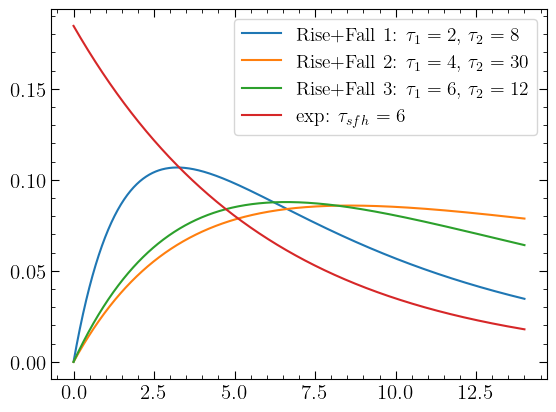

In [111]:
plt.plot(t_array, m_g_array_rise_fall_1, label = r'Rise+Fall 1: $\tau_1 = 2$, $\tau_2 = 8$')
plt.plot(t_array, m_g_array_rise_fall_2, label = r'Rise+Fall 2: $\tau_1 = 4$, $\tau_2 = 30$')
plt.plot(t_array, m_g_array_rise_fall_3, label = r'Rise+Fall 3: $\tau_1 = 6$, $\tau_2 = 12$')
#plt.plot(t_array, m_g_array_const, label = r'Const')
plt.plot(t_array, m_g_array_exp, label = r'exp: $\tau_{sfh} = 6$')

plt.legend()

In [148]:
etas = np.logspace(-2, 1, 10)
tau_stars = [0.5, 1, 1.5, 2, 2.5, 3, 4, 5, 6]
print(etas)

[ 0.01        0.02154435  0.04641589  0.1         0.21544347  0.46415888
  1.          2.15443469  4.64158883 10.        ]


In [149]:
gals_list = []

n_gals = len(etas) * len(tau_stars) * len(sfrs)
print("n_gals = ", n_gals)

n_gals =  450


In [150]:
for i_eta in range(len(etas)):
    for i_taustar in range(len(tau_stars)):
        for i_sfrs in range(len(sfrs)):
            eta = etas[i_eta]
            tau_star = tau_stars[i_taustar]
            sfr = sfrs[i_sfrs]

            gals_list.append(evo.Galaxy(t_array=t_array, m_g_array=sfr, tau_star=tau_star,
                                     eta=eta, Upsilon=1, 
                                     yields_ref="W2024,moreFe",
                                     g_cc_Mn=gcc_Mn_def, g_ratio_Mn=gcc_ratio_def,
                                     alpha_cc_Mn=alpha_cc_def, alpha_Ia_Mn=alpha_ia_def))

In [151]:
len(gals_list)

450

In [152]:
random.seed(42)
random_gals_list = random.sample(gals_list, 100)

/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_39018/2362098480.py:45: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
/var/folders/g0/fl404sj151l2v9xcdkjz9fq80000gn/T/ipykernel_39018/2362098480.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


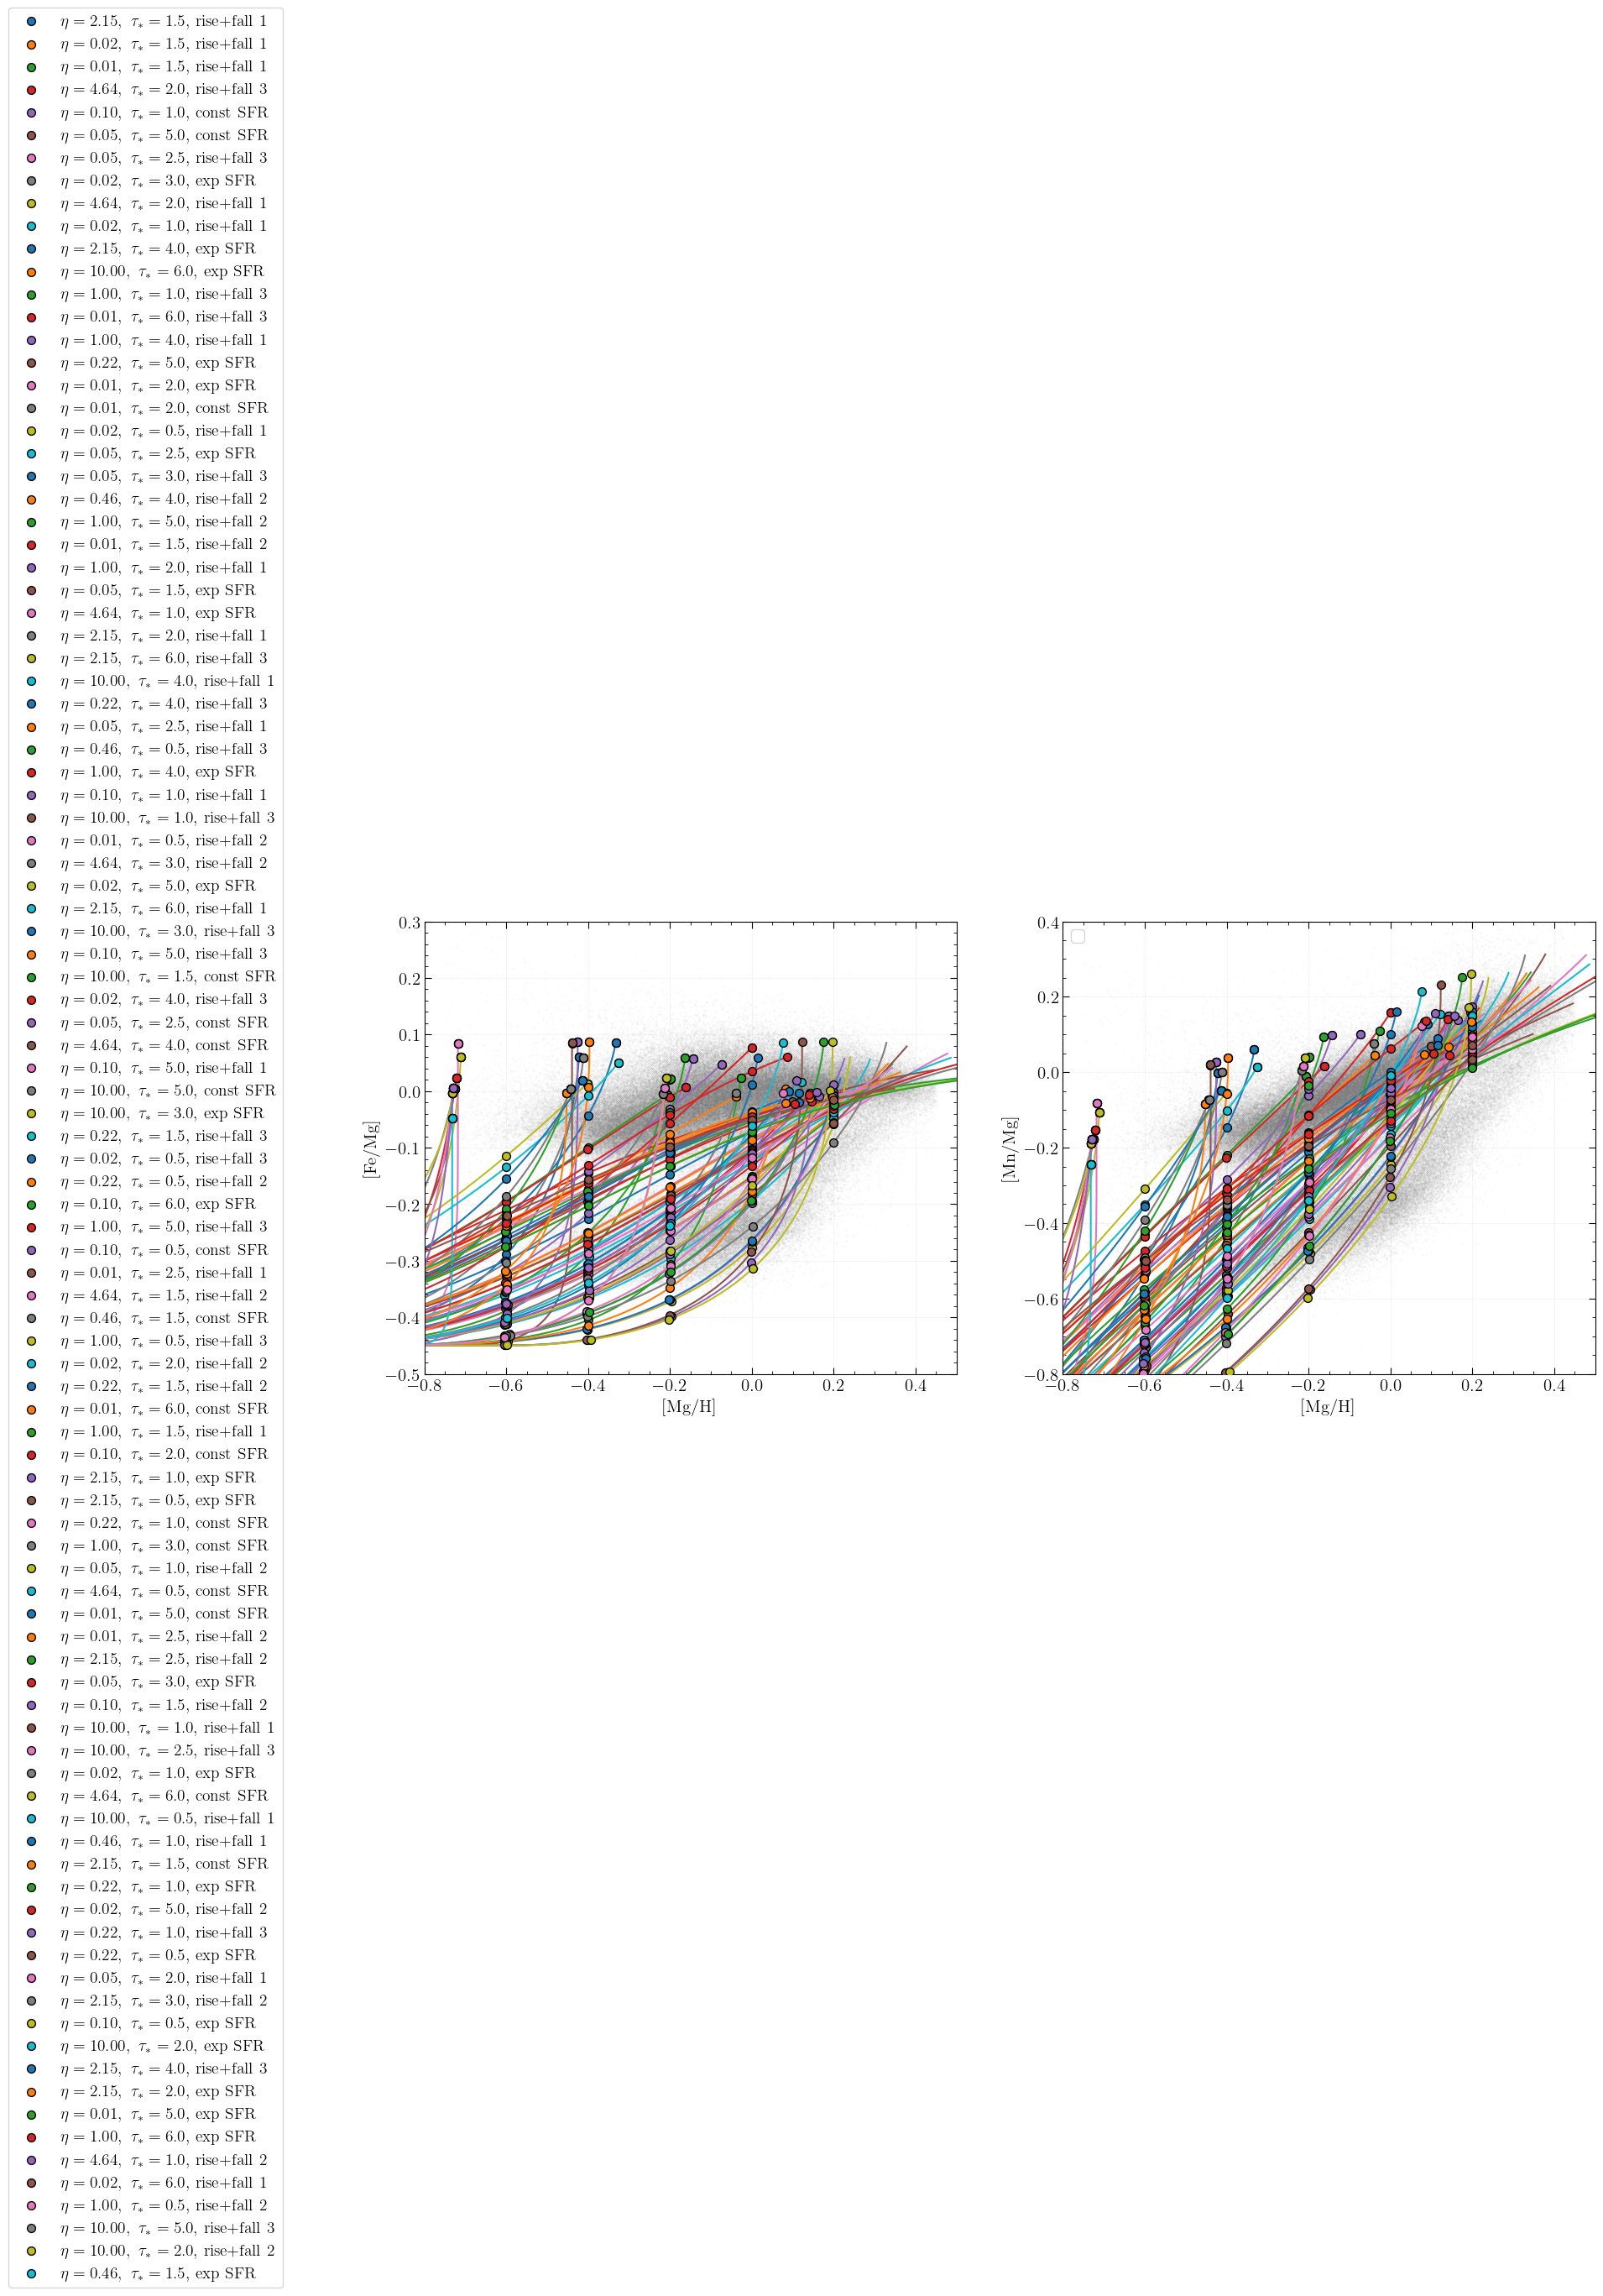

In [153]:
plt.figure(figsize=(18,7))

plt.subplot(1,2,1)
plt.scatter(data['MG_H'], data['FE_MG'], s = 0.01, color = 'gray', alpha = 0.3)

for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    eta = gal.eta_arr[0]
    taustar = gal.tau_star_arr[0]
    sfr = gal.m_g_array
    if np.array_equal(sfr, m_g_array_const):
        sfr_label = "const SFR"
    elif np.array_equal(sfr, m_g_array_exp):
        sfr_label = "exp SFR"
    elif np.array_equal(sfr, m_g_array_rise_fall_1):
        sfr_label = "rise+fall  1"
    elif np.array_equal(sfr, m_g_array_rise_fall_2):
        sfr_label = "rise+fall  2"
    elif np.array_equal(sfr, m_g_array_rise_fall_3):
        sfr_label = "rise+fall  3"
    else:
        sfr_label = "unknown SFR"
        
    plt.plot(gal.Mg_H, gal.Fe_Mg)
    idx = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :]).argmin(axis=0)
    plt.scatter(gal.Mg_H[idx], gal.Fe_Mg[idx], s=50, zorder=10, marker='o', edgecolors='black',
                label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

plt.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
plt.xlim(-0.8, 0.5)
plt.ylim(-0.5, 0.3)
plt.xlabel('[Mg/H]')
plt.ylabel('[Fe/Mg]')
plt.grid(True, alpha = 0.1)       


plt.subplot(1,2,2)
plt.scatter(data['MG_H'], data['MN_MG'], s = 0.01, color = 'gray', alpha = 0.3)
for i in range(len(random_gals_list)):
    gal = random_gals_list[i]
    plt.plot(gal.Mg_H, gal.Mn_Mg)
    idx = np.abs(gal.Mg_H[:, None] - mg_h_big_bin_centers[None, :]).argmin(axis=0)
    plt.scatter(gal.Mg_H[idx], gal.Mn_Mg[idx], s=50, zorder=10, marker='o', edgecolors='black')

plt.legend()
plt.xlim(-0.8, 0.5)
plt.ylim(-0.8, 0.4)
plt.xlabel('[Mg/H]')
plt.ylabel('[Mn/Mg]')
plt.grid(True, alpha = 0.1)

plt.tight_layout()

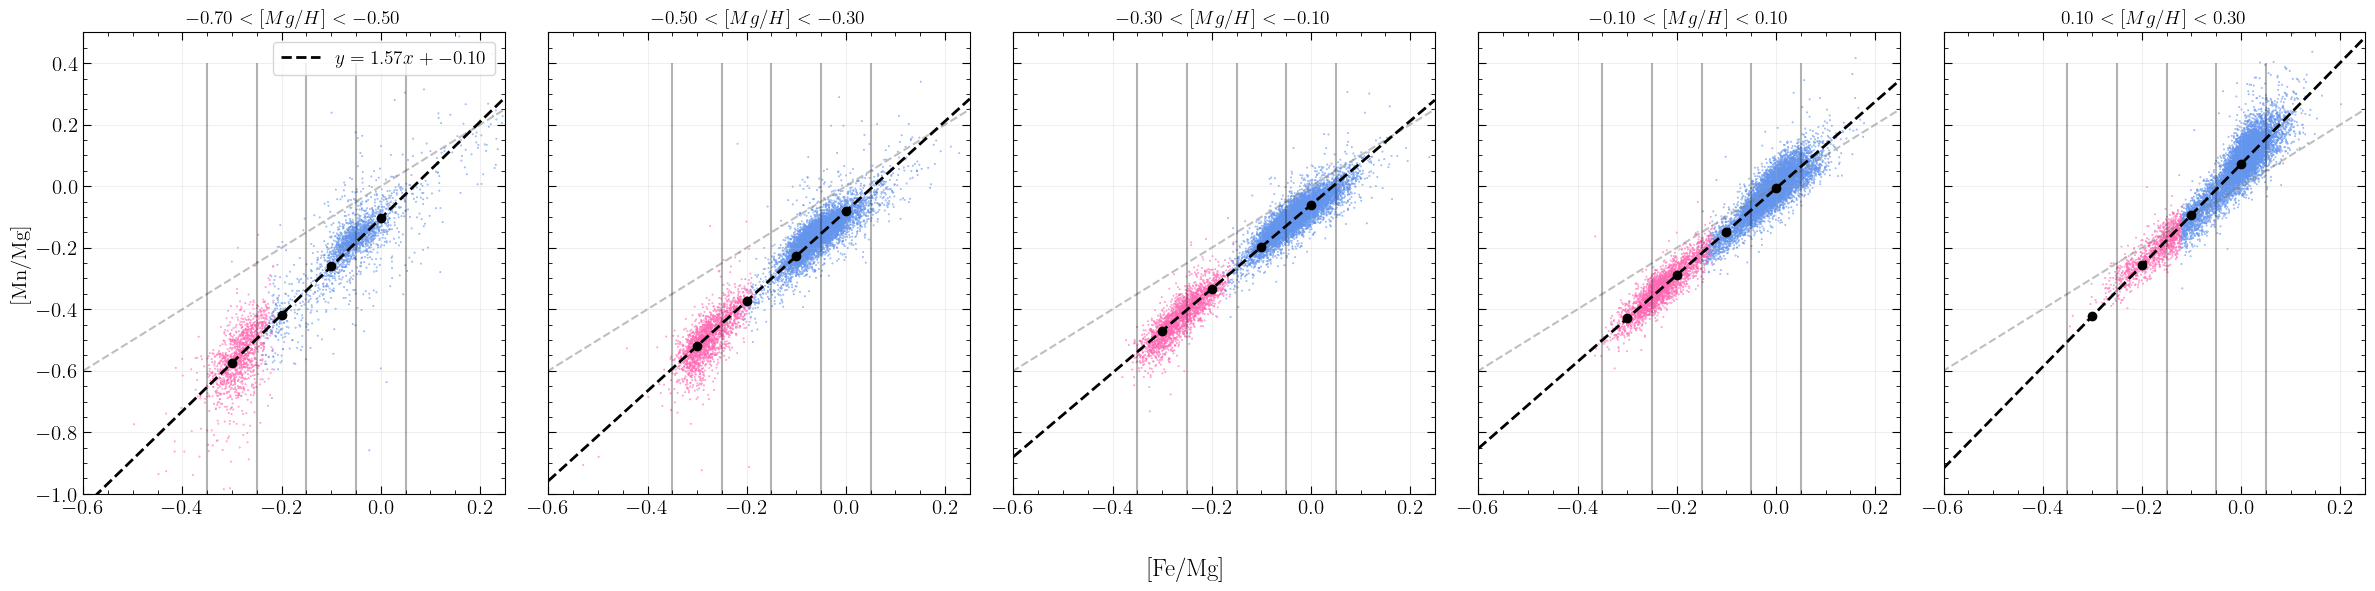

In [154]:
from scipy.stats import linregress

fig_x = 24
fig_y = 6

fe_mg_bin_edges = np.arange(-0.35, 0.15, 0.1)
fe_mg_bin_centers = 0.5 * (fe_mg_bin_edges[:-1] + fe_mg_bin_edges[1:])

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = len(axes)  # or len(mg_h_big_bin_centers)

slopes_mn_mg = np.zeros(n_bins)
intercepts_mn_mg = np.zeros(n_bins)

for i, ax in enumerate(axes):
    # Select data in this bin
    subset = data[data['MG_H_big_bin'] == i]
    downsampled_data = downsample(subset, 10000)

    x = downsampled_data['FE_MG']
    y = downsampled_data['MN_MG']

    # Scatter
    ax.scatter(x, y, s=0.1, color=downsampled_data['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # ---- LINEAR FIT ----
    # Remove NaNs just in case
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) > 2:
        slope, intercept, r_value, _, _ = linregress(x_fit, y_fit)
        slopes_mn_mg[i] = slope
        intercepts_mn_mg[i] = intercept

        # Plot fit
        xs_fit = np.linspace(-0.60, 0.25, 100)
        ys_fit = slope * xs_fit + intercept
        ax.plot(xs_fit, ys_fit, color='black', lw=2,
                label=rf'$y={slope:.2f}x+{intercept:.2f}$', linestyle='--')
        
        # Evaluate fit at bin centers
        y_centers = slope * fe_mg_bin_centers + intercept

        # Plot as points (recommended)
        ax.plot(fe_mg_bin_centers, y_centers, 'o', color='black', ms=6)
        ax.vlines(fe_mg_bin_edges,  ymin=-1.5, ymax=0.40, color='black', alpha=0.3)

        # Optional: connect them
        #ax.plot(fe_mg_bin_centers, y_centers, linestyle='--', color='black', alpha=0.7)

    if i == 0:
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylabel("[Mn/Mg]")

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-1.00, 0.50)


fig.supxlabel('[Fe/Mg]')
plt.tight_layout()

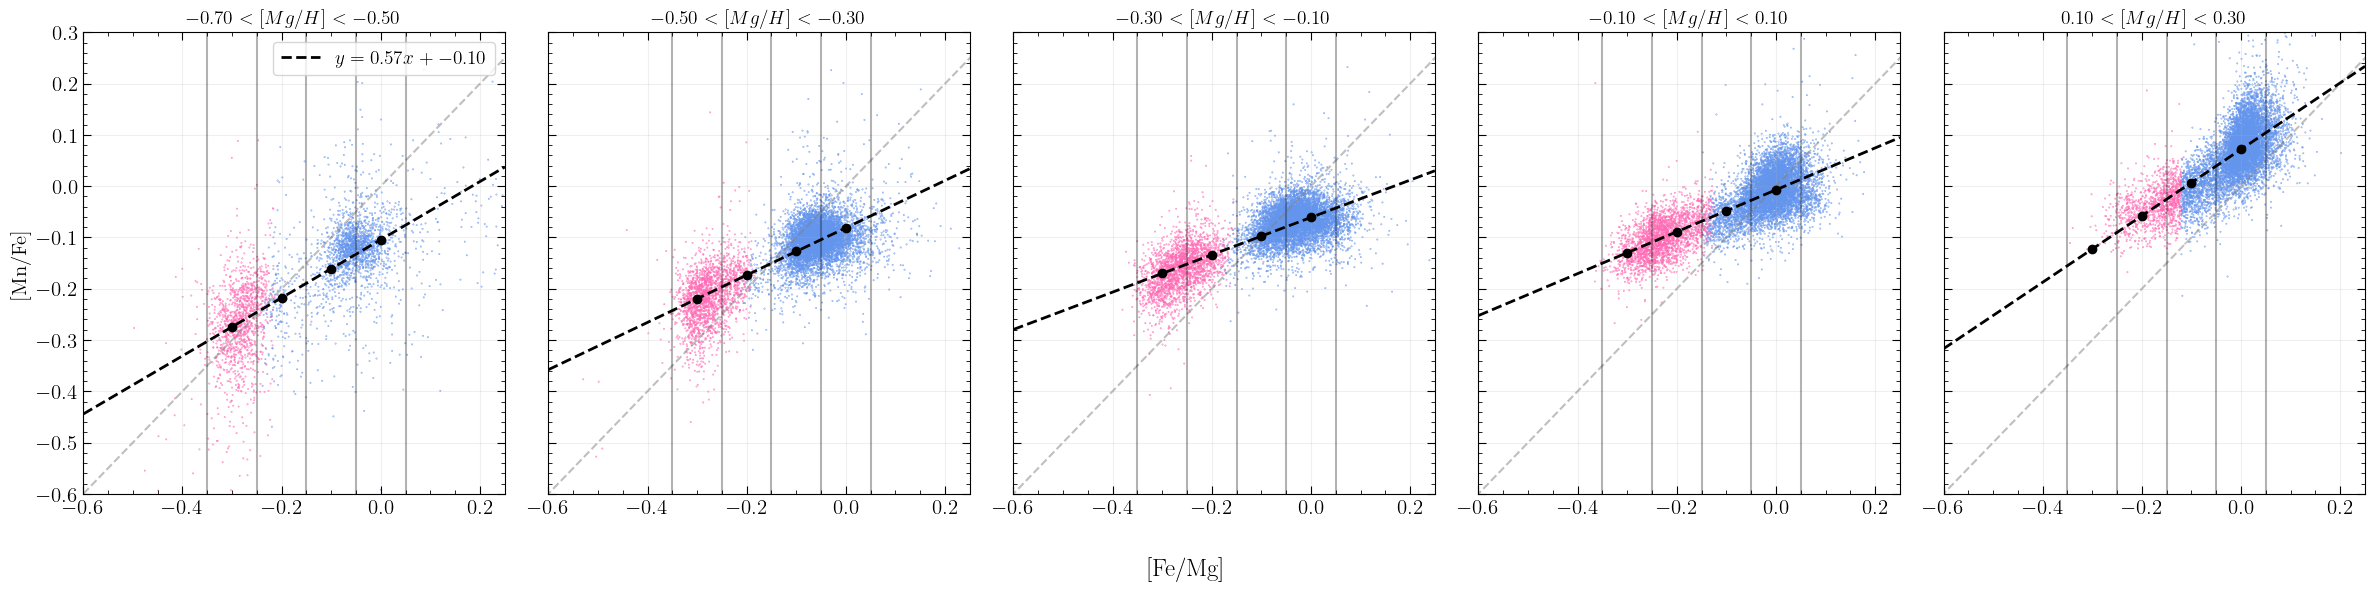

In [155]:
from scipy.stats import linregress

fig_x = 24
fig_y = 6

fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
axes = axes.flatten()

n_bins = len(axes)  # or len(mg_h_big_bin_centers)

slopes_mn_fe = np.zeros(n_bins)
intercepts_mn_fe = np.zeros(n_bins)

for i, ax in enumerate(axes):
    # Select data in this bin
    subset = data[data['MG_H_big_bin'] == i]
    downsampled_data = downsample(subset, 10000)

    x = downsampled_data['FE_MG']
    y = downsampled_data['MN_FE']

    # Scatter
    ax.scatter(x, y, s=0.1, color=downsampled_data['color'])

    # 1:1 line
    xs = np.linspace(-1, 1, 100)
    ax.plot(xs, xs, '--', alpha=0.5, color='gray')

    # ---- LINEAR FIT ----
    # Remove NaNs just in case
    mask = np.isfinite(x) & np.isfinite(y)
    x_fit = x[mask]
    y_fit = y[mask]

    if len(x_fit) > 2:
        slope, intercept, r_value, _, _ = linregress(x_fit, y_fit)
        slopes_mn_fe[i] = slope
        intercepts_mn_fe[i] = intercept

        # Plot fit
        xs_fit = np.linspace(-0.60, 0.25, 100)
        ys_fit = slope * xs_fit + intercept
        ax.plot(xs_fit, ys_fit, color='black', lw=2,
                label=rf'$y={slope:.2f}x+{intercept:.2f}$', linestyle='--')
        
        # Evaluate fit at bin centers
        y_centers = slope * fe_mg_bin_centers + intercept

        # Plot as points (recommended)
        ax.plot(fe_mg_bin_centers, y_centers, 'o', color='black', ms=6)
        ax.vlines(fe_mg_bin_edges,  ymin=-1.5, ymax=0.40, color='black', alpha=0.3)

        # Optional: connect them
        #ax.plot(fe_mg_bin_centers, y_centers, linestyle='--', color='black', alpha=0.7)

    if i == 0:
        ax.legend(loc='upper right', fontsize=14)
        ax.set_ylabel("[Mn/Fe]")

    ax.set_title(
        rf'${mg_h_big_bin_edges[i]:.2f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
        fontsize=14
    )
    ax.grid(True, alpha=0.2)
    ax.set_xlim(-0.60, 0.25)
    ax.set_ylim(-0.60, 0.30)


fig.supxlabel('[Fe/Mg]')
plt.tight_layout()

In [156]:
def find_endpoints(galaxies, bin_centers):
    endpoints_gals = []

    for bin_cent in bin_centers:
        endpoints = []
        for gal in galaxies:
            mg_h = gal.Mg_H
            for indx in range(len(mg_h)):
                mg_h_at_time = mg_h[indx]
                if mg_h_at_time > bin_cent:
                    endpoints.append(indx)
                    break

        endpoints_gals.append(np.array(endpoints))

    return endpoints_gals

In [157]:
colors = ["#6AC9EB",  # pastel blue
          "#FDA02D",  # pastel orange
          '#FF6961',  # pastel red
          '#77DD77',  # pastel green
          "#D093E7",
          "#FF4891",
          "#34265F",
          "#A21912",
          "#E31CC2",
          "#299B82",
          "#91E991",
          "#450A38"]  

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

def make_mn_mg_plot(gals_list, fig_x=24, fig_y=6, slopes_mn_mg=slopes_mn_mg, intercepts_mn_mg=intercepts_mn_mg, data=data, colors=colors):
    fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
    axes = axes.flatten()

    # Pre-calculate endpoints for all galaxies across all bin centers
    gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

    for i, ax in enumerate(axes):
        # Plot background data
        downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_MG'], s=0.1, color='gray', alpha=0.3)

        # Plot median line
        y_centers = slopes_mn_mg[i] * fe_mg_bin_centers + intercepts_mn_mg[i]
        ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

        # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
        idxs = gals_endpoints[i]

        # Use enumerate to get an index 'k' for each galaxy
        for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
            if idx != -1:  # Ensure the galaxy actually crossed this bin center
                fe_mg = gal.Fe_Mg[idx]
                mn_mg = gal.Mn_Mg[idx]
                
                # Pick a color based on the index k. 
                # Modulo prevents crashing if there are more galaxies than colors.
                gal_color = colors[k % len(colors)]
                eta = gal.eta_arr[0]
                taustar = gal.tau_star_arr[0]
                sfr = gal.m_g_array
                if np.array_equal(sfr, m_g_array_const):
                    sfr_label = "const SFR"
                elif np.array_equal(sfr, m_g_array_exp):
                    sfr_label = "exp SFR"
                elif np.array_equal(sfr, m_g_array_rise_fall_1):
                    sfr_label = "rise+fall  1"
                elif np.array_equal(sfr, m_g_array_rise_fall_2):
                    sfr_label = "rise+fall  2"
                elif np.array_equal(sfr, m_g_array_rise_fall_3):
                    sfr_label = "rise+fall  3"
                else:
                    sfr_label = "unknown SFR"

                # Note: fixed tau_star to taustar to match your variable definition
                ax.plot(fe_mg, mn_mg, marker='o', color=gal_color, linewidth=0,
                        markeredgecolor='black', markersize=8, zorder=11,
                        label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

        if i == 0:
            # loc='center right' aligns the right edge of the legend box
            # bbox_to_anchor=(-0.15, 0.5) places it to the left of the y-axis, centered vertically
            ax.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
            ax.set_ylabel('[Mn/Mg]')
        
        ax.set_title(
            rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
            fontsize=14
        )
        ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(-1.5, 0.40)

    fig.supxlabel('[Fe/Mg]')
    fig.subplots_adjust(wspace=0)

In [158]:
colors = ["#6AC9EB",  # pastel blue
          "#FDA02D",  # pastel orange
          '#FF6961',  # pastel red
          '#77DD77',  # pastel green
          "#D093E7",
          "#FF4891",
          "#34265F",
          "#A21912",
          "#E31CC2",
          "#299B82",
          "#91E991",
          "#450A38"]  

import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import numpy as np

def make_mn_fe_plot(gals_list, fig_x=24, fig_y=6, slopes_mn_mg=slopes_mn_mg, intercepts_mn_mg=intercepts_mn_mg, data=data, colors=colors):
    fig, axes = plt.subplots(1, 5, figsize=(fig_x, fig_y), sharex=True, sharey=True)
    axes = axes.flatten()

    # Pre-calculate endpoints for all galaxies across all bin centers
    gals_endpoints = find_endpoints(gals_list, mg_h_big_bin_centers)

    for i, ax in enumerate(axes):
        # Plot background data
        downsampled_data = downsample(data[data['MG_H_big_bin'] == i], 5000)
        ax.scatter(downsampled_data['FE_MG'], downsampled_data['MN_FE'], s=0.1, color='gray', alpha=0.3)

        # Plot median line
        y_centers = slopes_mn_fe[i] * fe_mg_bin_centers + intercepts_mn_fe[i]
        ax.plot(fe_mg_bin_centers, y_centers, '-o', color='black', ms=8, zorder=10)

        # idxs contains the stopping index for EACH galaxy in gals_list for this bin 'i'
        idxs = gals_endpoints[i]

        # Use enumerate to get an index 'k' for each galaxy
        for k, (gal, idx) in enumerate(zip(gals_list, idxs)):
            if idx != -1:  # Ensure the galaxy actually crossed this bin center
                fe_mg = gal.Fe_Mg[idx]
                mn_fe = gal.Mn_Fe[idx]
                
                # Pick a color based on the index k. 
                # Modulo prevents crashing if there are more galaxies than colors.
                gal_color = colors[k % len(colors)]
                eta = gal.eta_arr[0]
                taustar = gal.tau_star_arr[0]
                sfr = gal.m_g_array
                if np.array_equal(sfr, m_g_array_const):
                    sfr_label = "const SFR"
                elif np.array_equal(sfr, m_g_array_exp):
                    sfr_label = "exp SFR"
                elif np.array_equal(sfr, m_g_array_rise_fall_1):
                    sfr_label = "rise+fall  1"
                elif np.array_equal(sfr, m_g_array_rise_fall_2):
                    sfr_label = "rise+fall  2"
                elif np.array_equal(sfr, m_g_array_rise_fall_3):
                    sfr_label = "rise+fall  3"
                else:
                    sfr_label = "unknown SFR"

                # Note: fixed tau_star to taustar to match your variable definition
                ax.plot(fe_mg, mn_fe, marker='o', color=gal_color, linewidth=0,
                        markeredgecolor='black', markersize=8, zorder=11,
                        label = rf"$\eta = {eta:.2f}, \ \tau_* = {taustar}$, {sfr_label}")

        if i == 0:
            # loc='center right' aligns the right edge of the legend box
            # bbox_to_anchor=(-0.15, 0.5) places it to the left of the y-axis, centered vertically
            ax.legend(loc='center right', bbox_to_anchor=(-0.25, 0.5), fontsize=14)
            ax.set_ylabel('[Mn/Fe]')
        
        ax.set_title(
            rf'${mg_h_big_bin_edges[i]:.3f} < [Mg/H] < {mg_h_big_bin_edges[i+1]:.2f}$',
            fontsize=14
        )
        ax.set_xticks(np.arange(-0.6, 0.2, 0.2))
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.60, 0.25)
        ax.set_ylim(-0.8, 0.40)

    fig.supxlabel('[Fe/Mg]')
    fig.subplots_adjust(wspace=0)

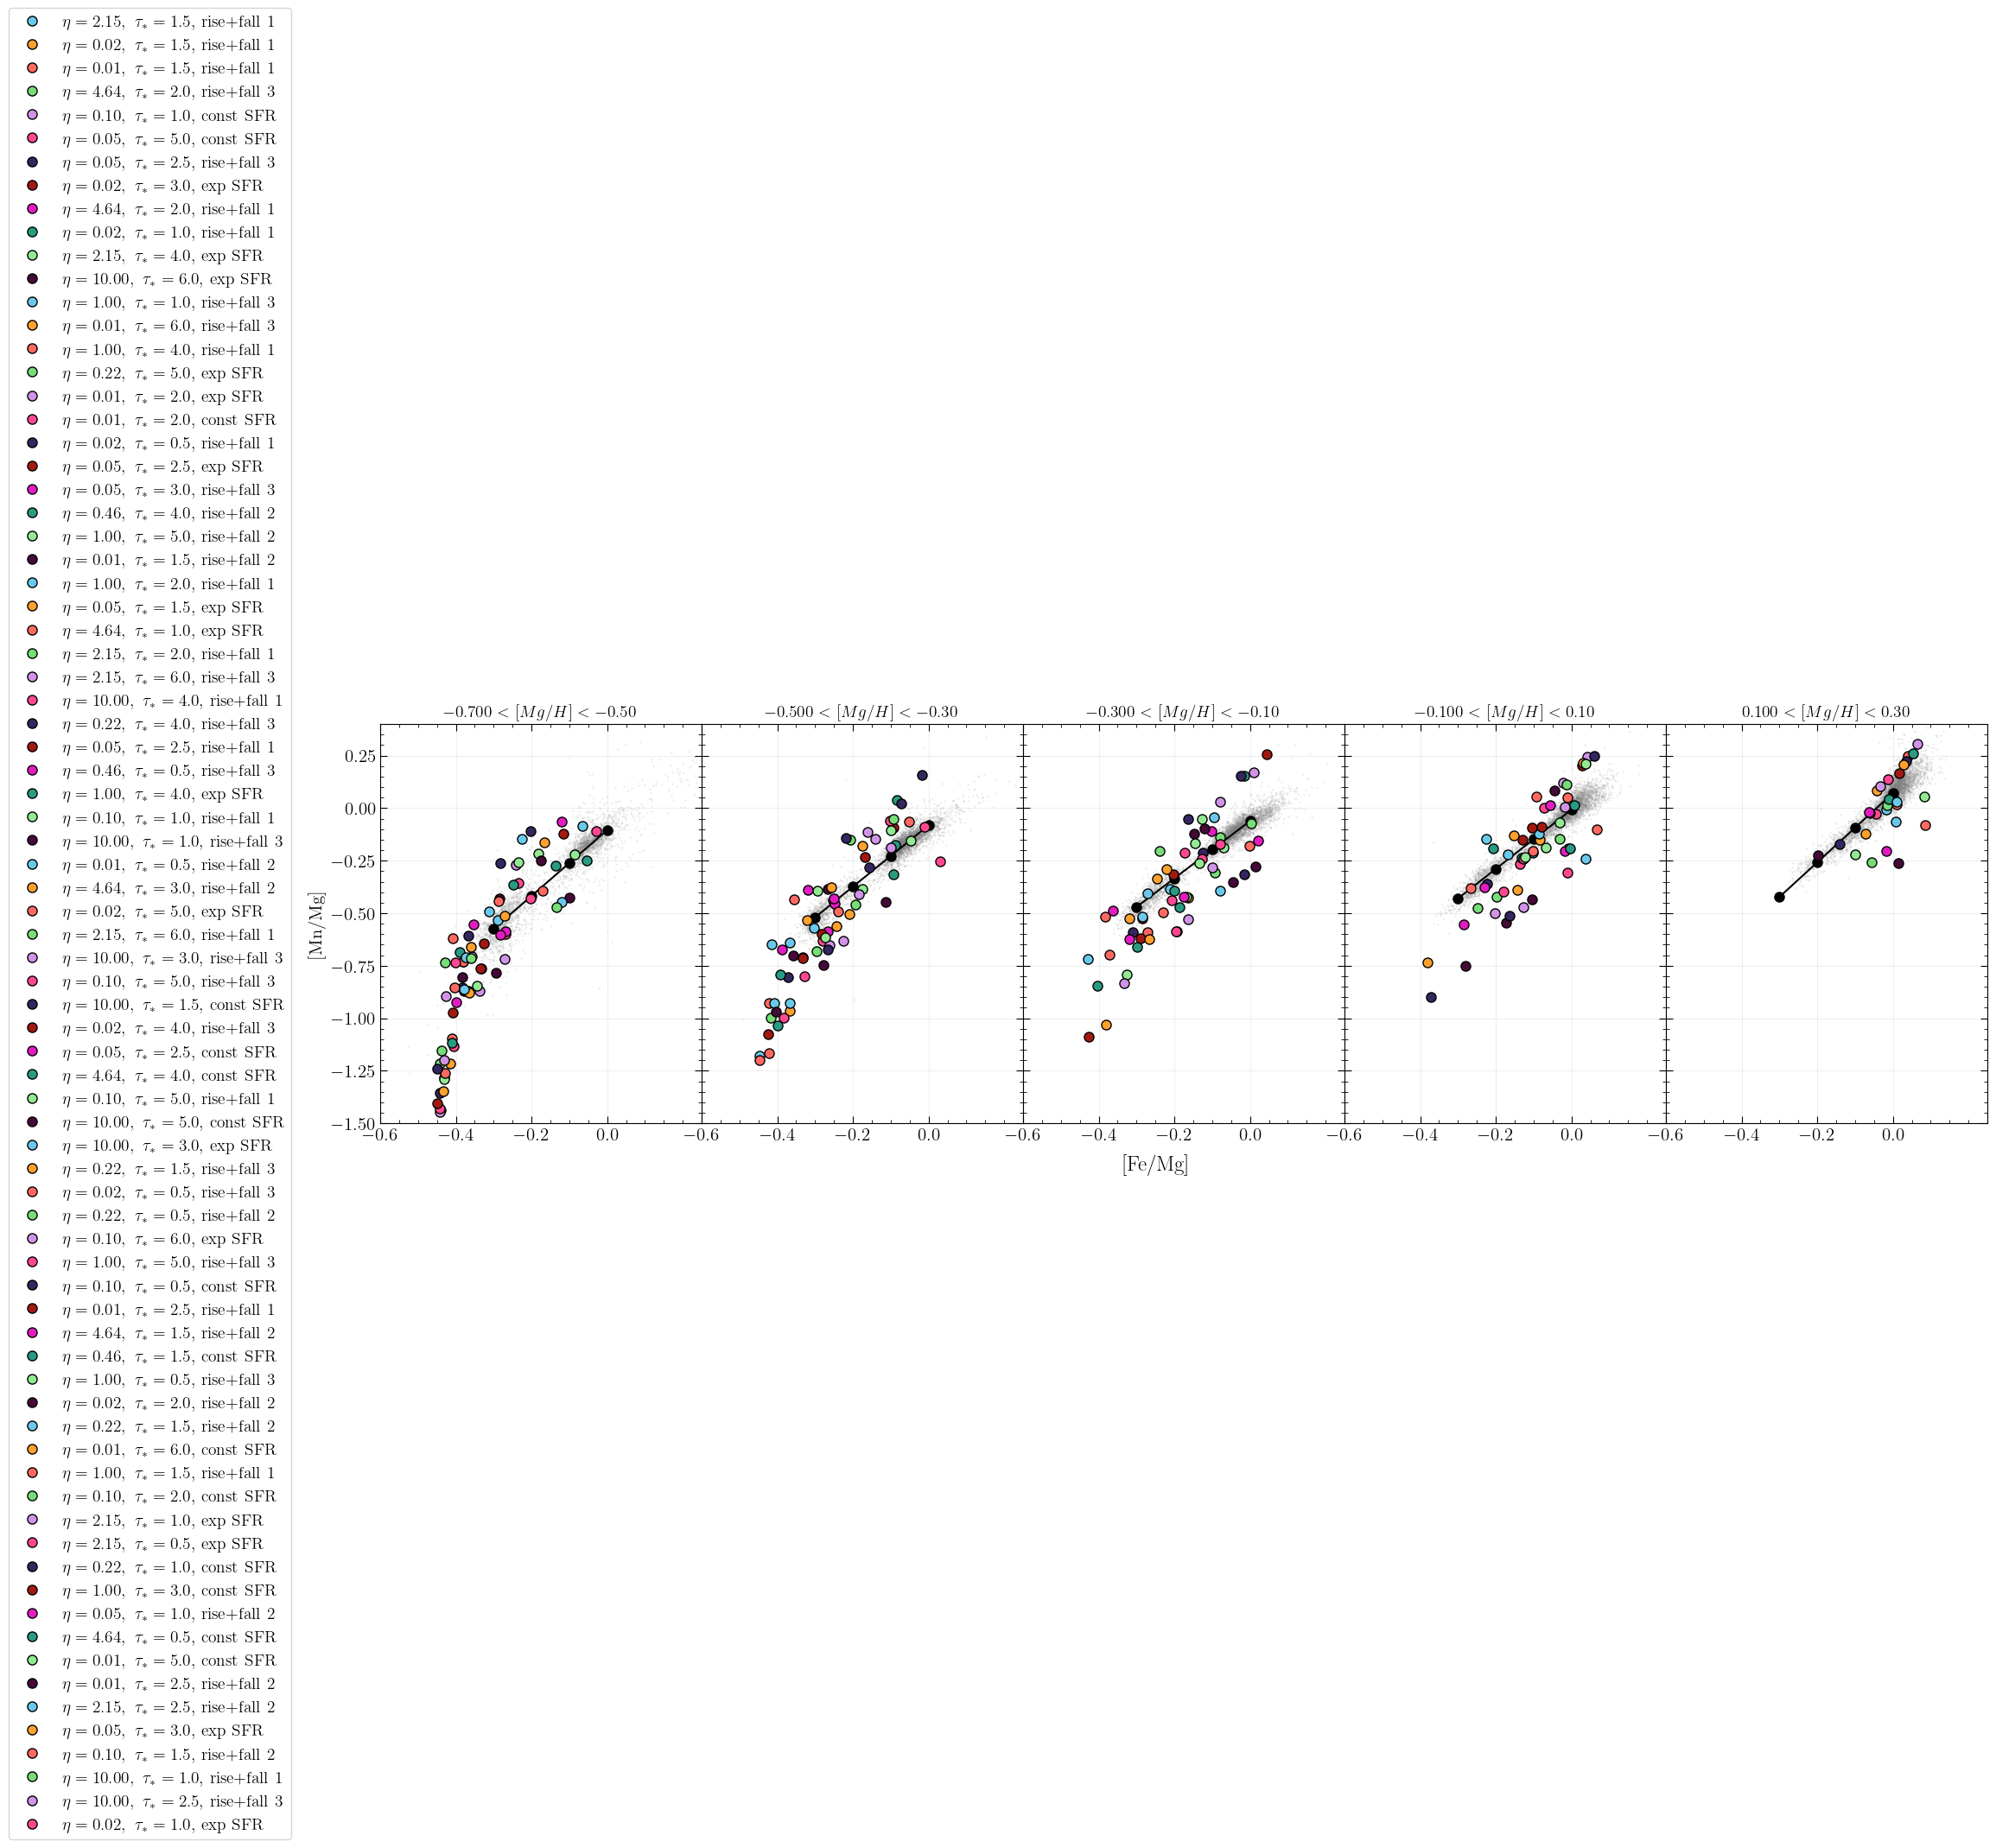

In [159]:
make_mn_mg_plot(gals_list=random_gals_list)

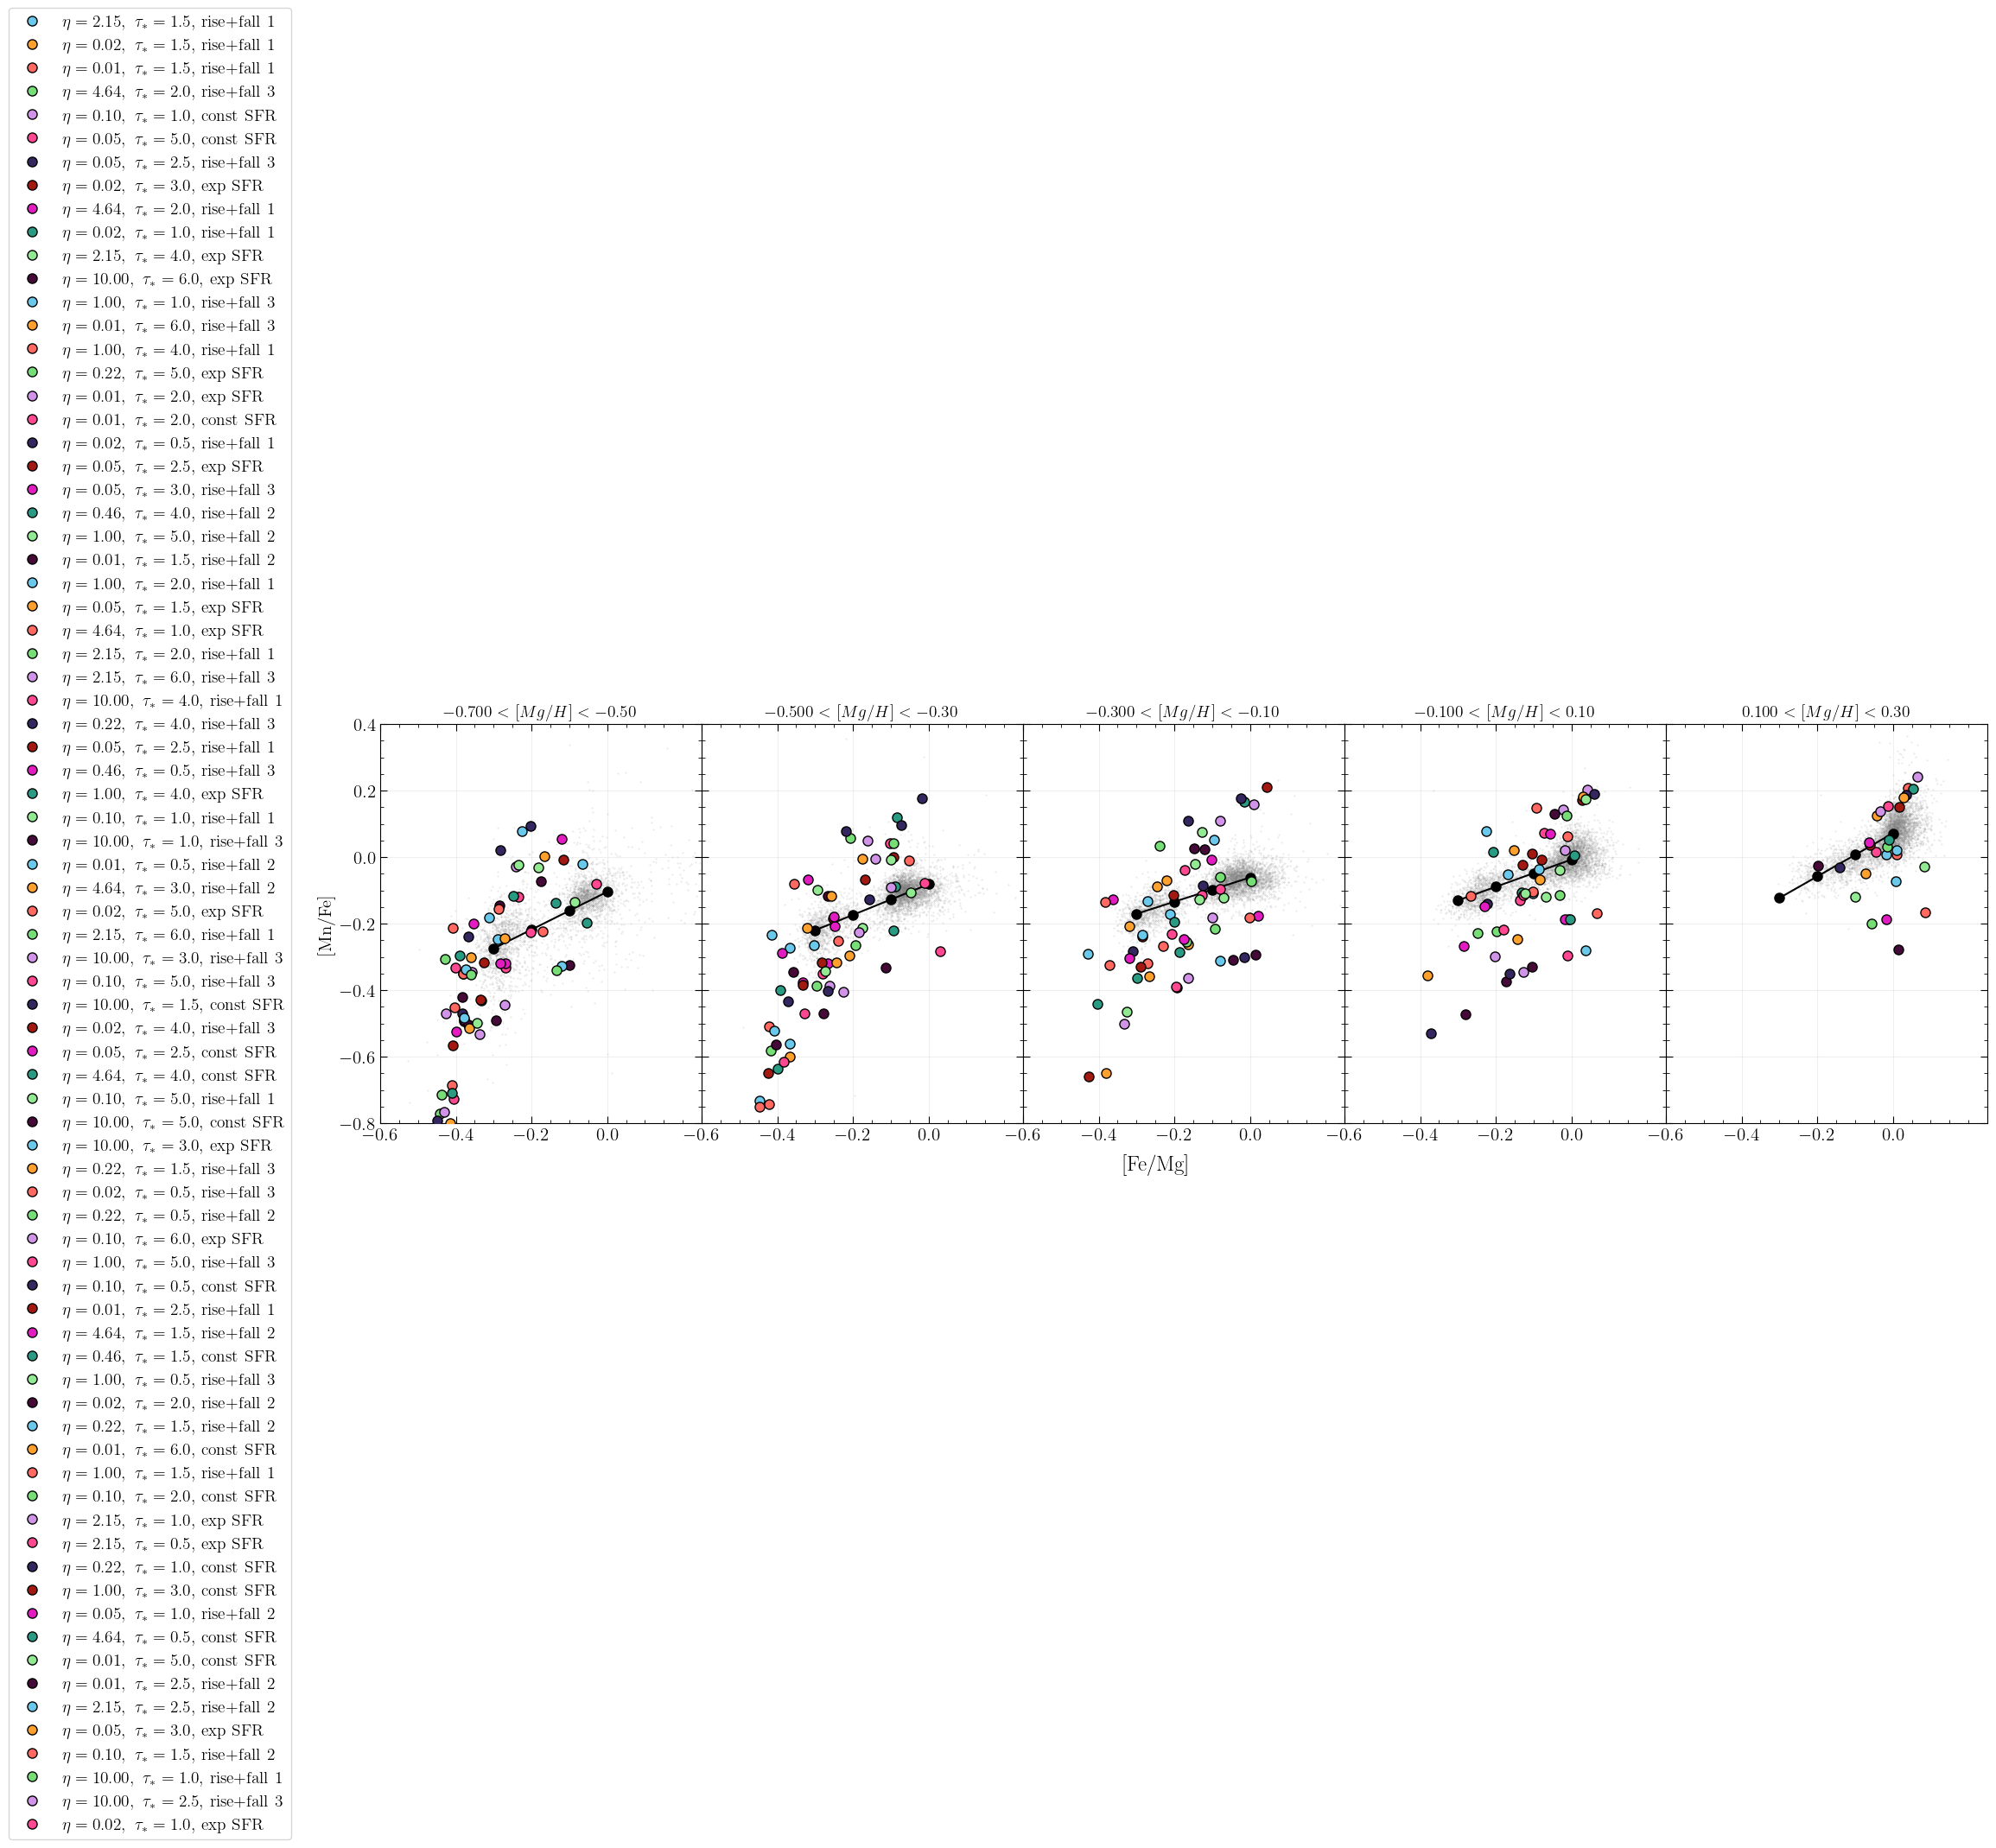

In [160]:
make_mn_fe_plot(gals_list=random_gals_list)